# 01 · Foundations: retrieval sets the ceiling

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 1 of 8**

You build the in-memory system, run the three retrieval modes on one worked question, and learn to score each handoff so a wrong answer points at the stage that owns it.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | The session deck, sections 1 and 2. | Notebook 02, which builds the benchmark you will measure against. |

Every company, person and figure in the corpus is fictional, so nothing here misstates a real fact. The techniques are real.

## Where this sits on the pipeline

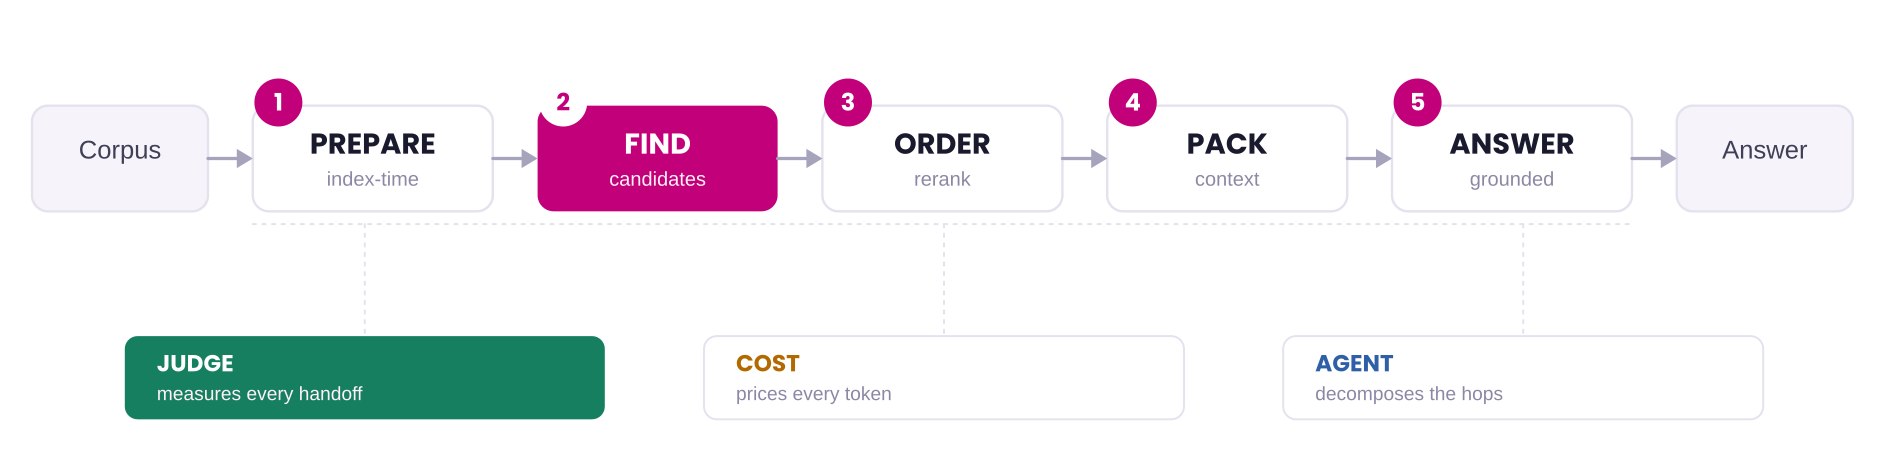

*The FIND stage and the JUDGE layer are what this notebook exercises.*

## 1 · Build the system in memory

Everything you retrieve from lives in a SQLite database created in memory. Documents are cut into chunks, the chunks are indexed twice, once as an inverted index for lexical search and once as vectors for semantic search, and a retriever wraps both. Nothing is written to disk, so any state can be inspected with a SQL query.

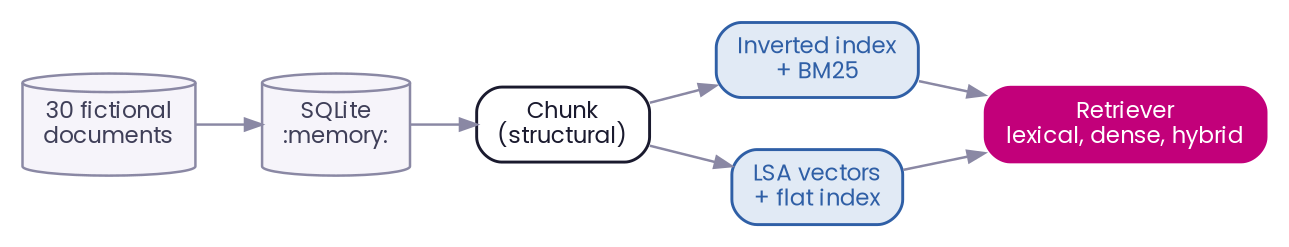

*What the setup cell builds. The dense embedder is latent semantic analysis, an established 1990s dense retriever used as a stand-in; a real embedder replaces it through one config line.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    corpus[("30 fictional<br/>documents")]
    db[("SQLite<br/>:memory:")]
    chunk["Chunk<br/>(structural)"]
    bm25["Inverted index<br/>+ BM25"]
    lsa["LSA vectors<br/>+ flat index"]
    ret(["Retriever<br/>lexical, dense, hybrid"])
    corpus --> db
    db --> chunk
    chunk --> bm25
    chunk --> lsa
    bm25 --> ret
    lsa --> ret
    class corpus data
    class db data
    class bm25 tool
    class lsa tool
    class ret endpt
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


In [2]:
store, chunks, embedder, retriever, generator, questions = rk.bootstrap(chunker="structural")
print(f"{len(store.docs())} documents, {len(chunks)} chunks, {len(questions)} benchmark questions, embedder = {embedder.name}, generator = {generator.name}")
table(store.sql("SELECT doc_id, title, source, date, tenant FROM docs ORDER BY date").head(8), "First eight documents by date")

30 documents, 64 chunks, 12 benchmark questions, embedder = lsa, generator = mock


doc_id,title,source,date,tenant
o1,Orbis Networks raises 500 million dollars in NYSE listing,Reuters,2021-10-14,public
h2,Brisk Automation raises 40 million dollar Series B,TechCrunch,2022-02-03,public
b7,Vega Dynamics shares jump in Nasdaq debut,Reuters,2023-06-08,public
g3,VD-7 Kestrel engine data sheet,Vega Dynamics engineering,2024-02-01,vega-internal
k1,Kestrel Foods recalls frozen meals over labelling error,Reuters,2024-03-05,public
l1,Lumen Bio raises 200 million dollars in Nasdaq IPO,Reuters,2024-05-16,public
l2,"Profile: Amir Sadeghi, the founder who sold Helix Diagnostics and started again",TechCrunch,2024-06-02,public
f3,Nasdaq to tighten listing rules for small companies,Bloomberg,2024-08-09,public


| What the store holds | Why it is a table and not a Python list |
|---|---|
| `docs` carry title, source, date, tenant and an access-control list. | Metadata filtering, provenance and permission checks all need these fields at query time. |
| `chunks` carry a stable id built from document id, ordinal and a content hash. | An unchanged chunk keeps its id across rebuilds, which is what makes incremental re-indexing possible in notebook 03. |
| `index_versions` records which chunker and embedder built each version, and which one is live. | A rebuild with a new embedding model becomes a new version you can swap to and roll back from. |
| `traces` stores what each query retrieved, packed and answered. | The trace is the single artefact that lets you localise a failure after the fact. |

## 2 · One question carried through all eight notebooks

The question needs two facts that live in two different articles, joined only by a person's name. Either article alone yields a confident wrong answer. A third article is a distractor with high word overlap and the wrong company.

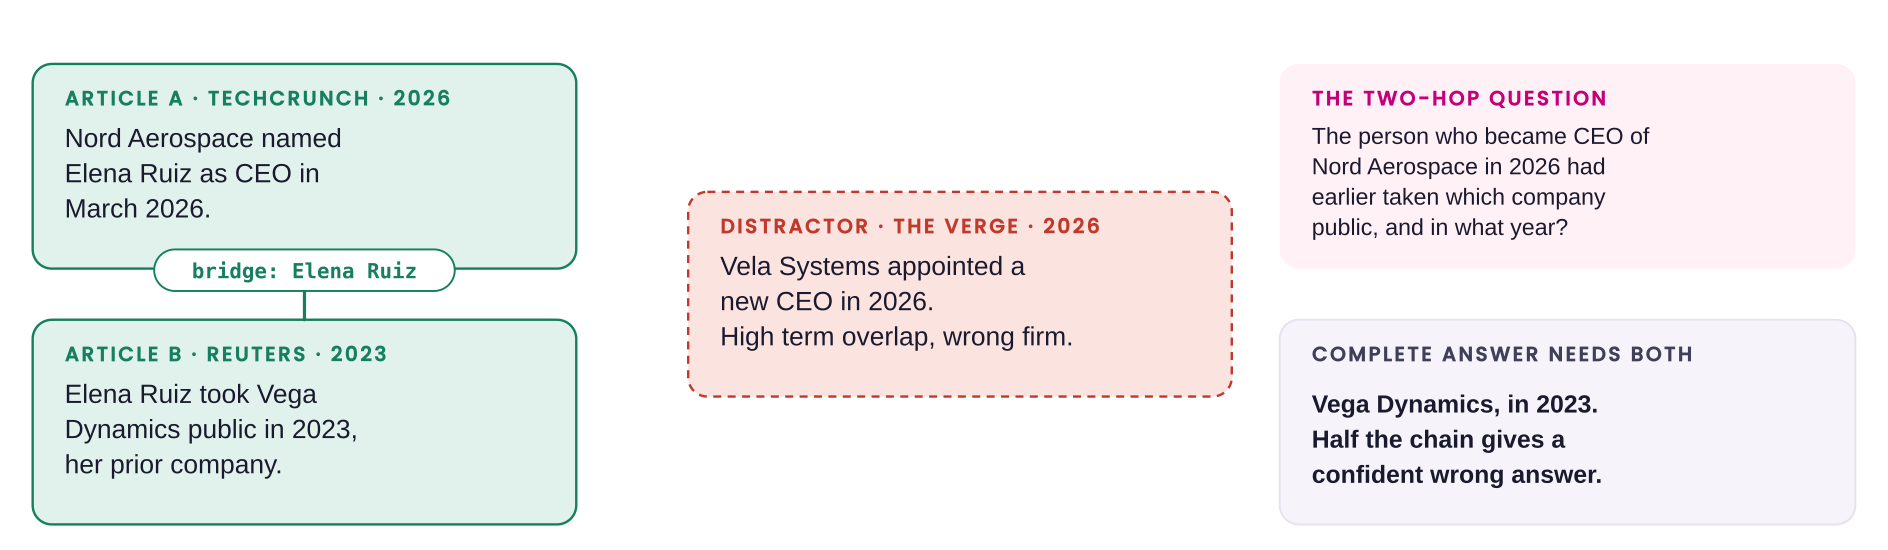

*Own construction, fictional companies. The answer is Vega Dynamics, 2023.*

In [3]:
anchor = rk.ANCHOR
print("QUESTION:", anchor.text, "\nANSWER:  ", anchor.answer, "\n")
for doc_id in ["a1", "b7", "d3"]:
    d = store.doc(doc_id)
    print(f"[{doc_id}] {d.title}  ({d.source}, {d.date})\n    {d.body[:230]}...\n")
gold = rk.resolve_gold(anchor, chunks)
table(pd.DataFrame([{"doc": d, "gold span": s[:70] + "...", "carried by chunk": ", ".join(c) or "NO CHUNK (boundary loss)"} for (d, s), c in gold.items()]),
      "Each gold span resolves to the chunk that carries it whole")

QUESTION: The person who became CEO of Nord Aerospace in 2026 had earlier taken which company public, and in what year? 
ANSWER:   Vega Dynamics, 2023 

[a1] Nord Aerospace names Elena Ruiz chief executive  (TechCrunch, 2026-03-12)
    Nord Aerospace, the Bergen-based launch-vehicle maker, named Elena Ruiz as chief executive on Thursday, ending a nine-month search. Ruiz joins from Vega Dynamics, the propulsion firm she led for six years.

She succeeds interim ch...

[b7] Vega Dynamics shares jump in Nasdaq debut  (Reuters, 2023-06-08)
    Shares of Vega Dynamics rose 28 percent in their Nasdaq debut on Thursday, June 8, 2023, valuing the propulsion company at about 2.1 billion dollars. The initial public offering raised 310 million dollars and the stock trades unde...

[d3] Vela Systems appoints Marcus Hale as chief executive  (Bloomberg, 2026-04-02)
    Vela Systems, the Turin-based maker of satellite antennas, appointed Marcus Hale as chief executive on Wednesday, the company said in

doc,gold span,carried by chunk
a1,"named Elena Ruiz as chief executive on Thursday, ending a nine-month s...",a1:0:63d9a4f8
b7,Shares of Vega Dynamics rose 28 percent in their Nasdaq debut on Thurs...,b7:0:d9956799


| Planted feature in the example | The technique it exercises | Where it bites if you get it wrong |
|---|---|---|
| The two facts sit in different articles, joined only by the name Elena Ruiz. | Multi-hop retrieval and the missing-hop problem. | One retrieval finds half the chain and the model invents the rest. |
| The proper noun Nord Aerospace appears verbatim in the source. | Lexical retrieval on exact identifiers. | A purely semantic search can drift to similar-sounding firms. |
| The question says became CEO while the source says named as chief executive. | Semantic retrieval across paraphrase. | A purely lexical search misses the relevant passage. |
| A distractor says Vela Systems appointed a new chief executive in 2026. | Reranking and precision under high term overlap. | The distractor outranks the real evidence and pollutes the context. |
| Each article carries a date and a source, and an earlier article names an interim chief executive. | Metadata filtering and provenance. | Undated evidence cannot be filtered, so the 2025 interim appointment beats the 2026 one. |

## 3 · Retrieval sets the ceiling before the model writes a word

The generator can only work with what retrieval hands it. The cell below runs the same generator twice on the same question. The only thing that changes is the evidence it is given.

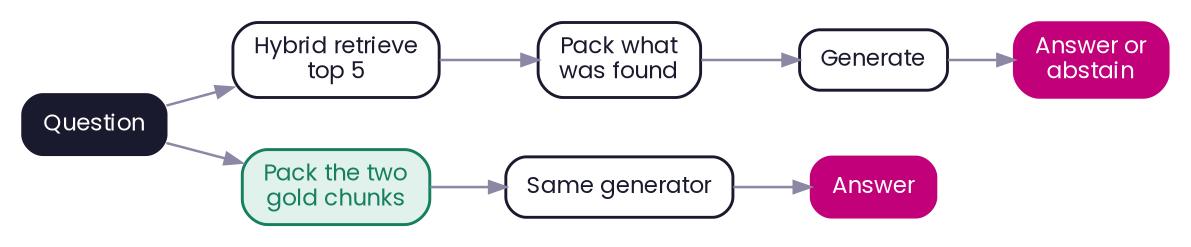

*Two runs, one generator. The generator is a documented mock here: it answers only when every required fact is present, and abstains with a stated gap otherwise.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    q(["Question"])
    r["Hybrid retrieve<br/>top 5"]
    p1["Pack what<br/>was found"]
    g1["Generate"]
    a1(["Answer or<br/>abstain"])
    gold["Pack the two<br/>gold chunks"]
    g2["Same generator"]
    a2(["Answer"])
    q --> r
    r --> p1
    p1 --> g1
    g1 --> a1
    q --> gold
    gold --> g2
    g2 --> a2
    class q start
    class a1 endpt
    class gold ok
    class a2 endpt
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [4]:
texts = {c.chunk_id: c.text for c in chunks}
gold_sets = rk.gold_chunk_sets(anchor, chunks)

pool = retriever.hybrid(anchor.text, k=50)
top5 = [cid for cid, _ in pool[:5]]
print("top-5 chunk ids:", top5)
print("coverage of gold spans in the top 5:", rk.coverage(gold_sets, top5))
print("answer from the top 5 :", generator.answer(anchor, top5, texts).text, "\n")

gold_ids = [sorted(s)[0] for s in gold_sets]
print("coverage when the two gold chunks are packed:", rk.coverage(gold_sets, gold_ids))
print("answer from the gold chunks:", generator.answer(anchor, gold_ids, texts).text)

top-5 chunk ids: ['g2:0:7465c618', 'a1:2:8d2011b6', 'b7:1:eb0b8d13', 'g2:1:759cdda7', 'k3:1:3ea2bfbe']
coverage of gold spans in the top 5: 0.0
answer from the top 5 : INSUFFICIENT EVIDENCE. None of the required facts are in the evidence. 

coverage when the two gold chunks are packed: 1.0
answer from the gold chunks: Vega Dynamics, 2023 [a1:0:63d9a4f8] [b7:0:d9956799]


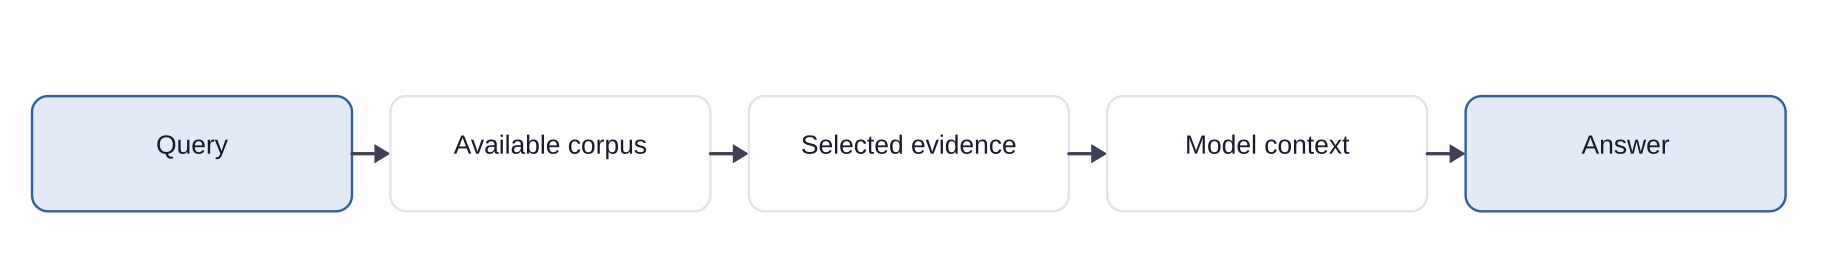

*Established idea, own drawing. Anything dropped early cannot reappear later.*

| Run | Evidence handed to the generator | Outcome | What it proves |
|---|---|---|---|
| Top 5 from hybrid retrieval | The right documents rank near the top, but not the chunks that carry the two facts. | An abstention with a stated gap. | The ceiling was set at the retrieve and select steps, not in generation. |
| The two gold chunks, packed by hand | Both facts, each with a source id. | The correct answer with two citations. | The same generator is fully capable once the evidence arrives. |

The number to remember from this run is the coverage. It moved from 0.0 to 1.0 and nothing else changed.

## 4 · Three ways to retrieve, and they answer different questions

### 4a · Lexical: an inverted index scored by BM25

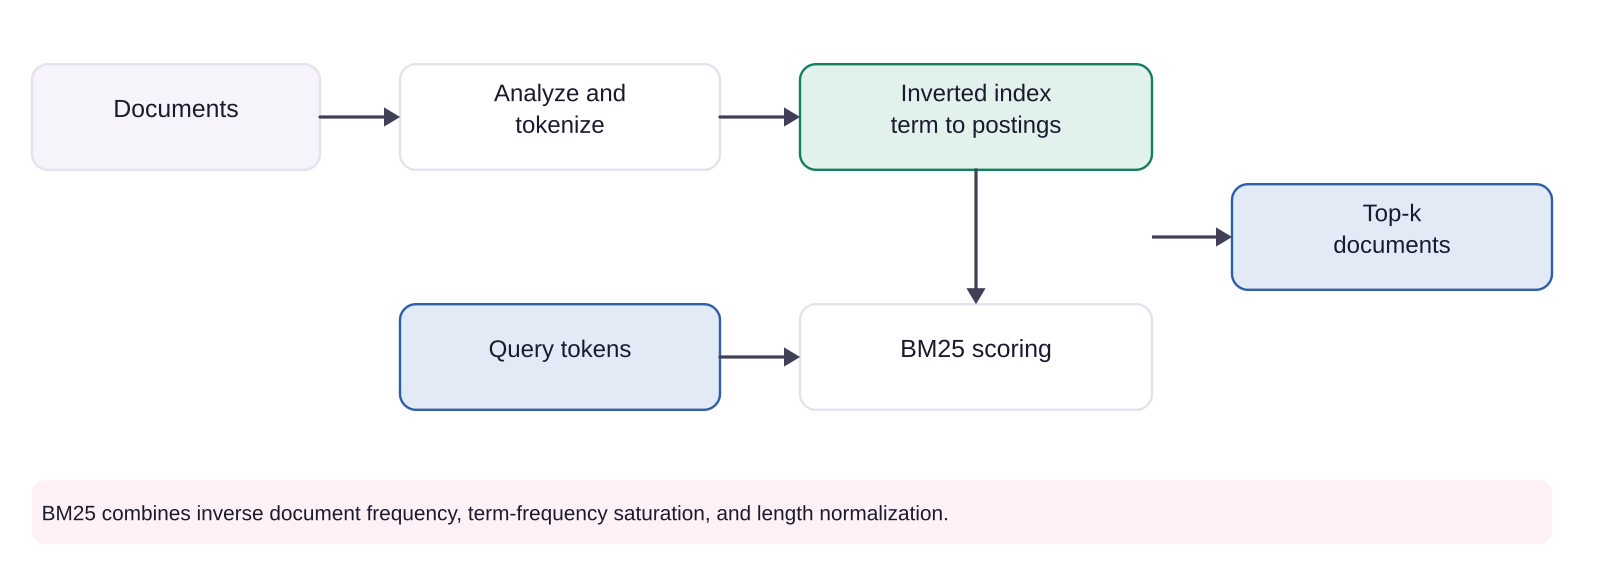

*Established: Okapi BM25 with k1 for term-frequency saturation and b for length normalisation. The implementation in ragkit prints every term's contribution.*

In [5]:
hits = retriever.lexical("Nord Aerospace", k=4)
display(table(retriever.show(hits), "BM25 for the exact name"))
display(table(retriever.bm25.explain("Nord Aerospace", hits[0][0]), "Per-term contribution to the top chunk: the rarer term carries the score"))

trap = retriever.lexical("Kestrel engine", k=5)
table(retriever.show(trap), "The Kestrel trap: an engine called Kestrel and a food company called Kestrel compete on the same token")

rank,chunk_id,doc,date,score,text
1,g2:0:7465c618,g2,2026-05-14,6.446,Nord Aerospace expands Bergen test site. Nord Aerospace began construction of a second tes...
2,a1:2:8d2011b6,a1,2026-03-12,5.835,Nord Aerospace names Elena Ruiz chief executive. Ruiz said the appointment was a chance to...
3,a1:0:63d9a4f8,a1,2026-03-12,5.608,"Nord Aerospace names Elena Ruiz chief executive. Nord Aerospace, the Bergen-based launch-v..."
4,g2:1:759cdda7,g2,2026-05-14,4.731,Nord Aerospace expands Bergen test site. The stand will support engines of up to 400 kilon...


term,tf_in_chunk,docs_with_term,idf,contribution
aerospace,2,6,2.303,3.326
nord,2,7,2.159,3.120


rank,chunk_id,doc,date,score,text
1,g3:0:c647ea07,g3,2024-02-01,5.668,VD-7 Kestrel engine data sheet. The VD-7 Kestrel is a 90 kilonewton methane-oxygen engine ...
2,g3:1:a5977060,g3,2024-02-01,5.149,VD-7 Kestrel engine data sheet. The engine designation VD-7 replaced the earlier VD-5. Qua...
3,b7:2:d1f9f0e4,b7,2023-06-08,3.732,Vega Dynamics shares jump in Nasdaq debut. The listing was the largest by a European space...
4,e2:0:ae2b96a6,e2,2025-11-20,3.732,Vega Dynamics posts record quarterly revenue. Vega Dynamics reported third-quarter revenue...
5,k1:1:ca05bd17,k1,2024-03-05,2.893,Kestrel Foods recalls frozen meals over labelling error. The recall affects three product ...


| BM25 wins when | BM25 loses when | Because |
|---|---|---|
| The query carries an exact name, code, ticker or error string. | The user paraphrases and shares no tokens with the source. | Scoring is over tokens; a token that is absent contributes nothing. |
| A rare term identifies the document, as `nord` does above. | A common token is shared by unrelated documents, as `kestrel` is. | Inverse document frequency rewards rarity, and it cannot tell an engine from a food company. |

### 4b · Semantic: encode once, then search by nearest neighbour

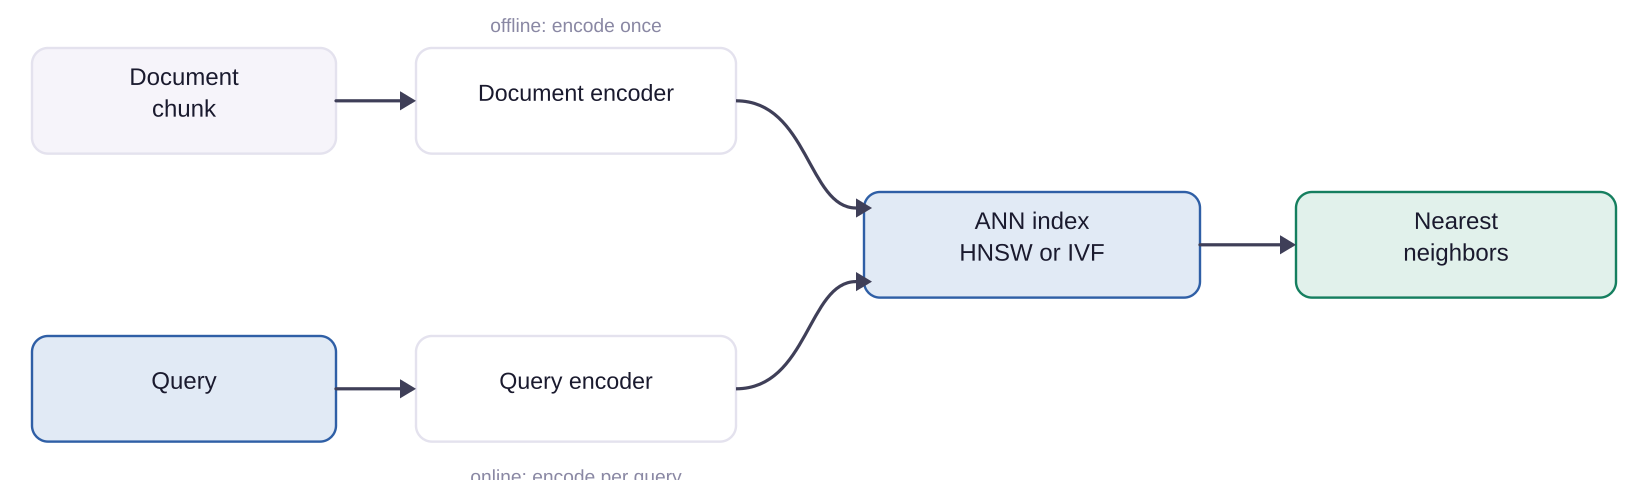

*Established shape. Here the encoder is latent semantic analysis fitted on the corpus, so paraphrase is captured only as far as co-occurrence allows. Treat its ranking as a stand-in for a neural embedder, not as its equal.*

In [6]:
q = "who now runs the launch company after the leadership change"
dense = retriever.dense(q, k=5)
lex = retriever.lexical(q, k=5)
def rank_of(ranked, doc_id):
    r = [i + 1 for i, (cid, _) in enumerate(ranked) if cid.startswith(doc_id + ":")]
    return r[0] if r else "not in top 5"
print(f"a1 (the appointment article) ranks {rank_of(dense,'a1')} in dense and {rank_of(lex,'a1')} in lexical")
display(table(retriever.show(dense), "Dense retrieval on a paraphrase. Notice which article ranks first."))

filtered = retriever.dense(q, k=5, date_from="2026-01-01")
table(retriever.show(filtered), "The same query with a metadata pre-filter: dated on or after 2026-01-01")

a1 (the appointment article) ranks 4 in dense and not in top 5 in lexical


rank,chunk_id,doc,date,score,text
1,g1:1:146112aa,g1,2025-06-30,0.667,European launch startups compete for institutional payloads. Nord Aerospace's interim chie...
2,g1:0:ab5b7020,g1,2025-06-30,0.581,European launch startups compete for institutional payloads. A group of European launch st...
3,e2:0:ae2b96a6,e2,2025-11-20,0.471,Vega Dynamics posts record quarterly revenue. Vega Dynamics reported third-quarter revenue...
4,a1:2:8d2011b6,a1,2026-03-12,0.313,Nord Aerospace names Elena Ruiz chief executive. Ruiz said the appointment was a chance to...
5,d3:2:f8428065,d3,2026-04-02,0.281,Vela Systems appoints Marcus Hale as chief executive. Vela Systems employs about 600 peopl...


rank,chunk_id,doc,date,score,text
1,a1:2:8d2011b6,a1,2026-03-12,0.313,Nord Aerospace names Elena Ruiz chief executive. Ruiz said the appointment was a chance to...
2,d3:2:f8428065,d3,2026-04-02,0.281,Vela Systems appoints Marcus Hale as chief executive. Vela Systems employs about 600 peopl...
3,k3:1:3ea2bfbe,k3,2026-02-03,0.240,Kestrel Foods revenue flat at 3.1 billion euros. The company said it expected modest growt...
4,g2:1:759cdda7,g2,2026-05-14,0.217,Nord Aerospace expands Bergen test site. The stand will support engines of up to 400 kilon...
5,a1:0:63d9a4f8,a1,2026-03-12,0.070,"Nord Aerospace names Elena Ruiz chief executive. Nord Aerospace, the Bergen-based launch-v..."


| What happened | The lesson |
|---|---|
| Dense retrieval placed the appointment article in its top 5 where lexical retrieval did not, because the query shares almost no tokens with the source. | Semantic retrieval covers the paraphrase blind spot of lexical retrieval. |
| The first result was the 2025 article naming the interim chief executive, not the 2026 appointment. | Semantic closeness is not correctness. The two articles mean almost the same thing and only the date tells them apart. |
| A date pre-filter fixed the ranking without touching the embedder. | Metadata is a retrieval signal in its own right, and filtering before ranking is how you use it. |

### 4c · Grep: literal patterns in files, logs and code

Grep is not a ranking. It answers a different question: does this exact pattern occur, and on which line. Identifiers, error codes and engine designations are where it is the right tool.

In [7]:
display(table(pd.DataFrame(rk.grep(chunks, r"ERR-4471")), "Literal search for an error code"))
display(table(pd.DataFrame(rk.grep(chunks, r"VD-[57]")), "A regular expression over engine designations"))
print("BM25 also finds the identifier, because it is a token:", retriever.lexical("ERR-4471", k=1)[0][0])
print("but grep works on files that were never indexed, and returns the line, not a chunk score.")

chunk_id,doc_id,line,match
h5:0:72974838,h5,2,"Version 4.2 of the Halden fleet manager fixes error code ERR-4471, which caused idle robots to report a false low-battery state"


chunk_id,doc_id,line,match
b7:2:d1f9f0e4,b7,3,Vega Dynamics builds the VD-7 Kestrel engine used by two small-launch providers.
e2:0:ae2b96a6,e2,2,"Vega Dynamics reported third-quarter revenue of 84 million dollars, a record for the propulsion company, driven by deliveries of its VD-7 Kestrel engine to two launch customers."
g3:0:c647ea07,g3,1,VD-7 Kestrel engine data sheet
g3:0:c647ea07,g3,2,The VD-7 Kestrel is a 90 kilonewton methane-oxygen engine built by Vega Dynamics
g3:1:a5977060,g3,1,VD-7 Kestrel engine data sheet
g3:1:a5977060,g3,2,The engine designation VD-7 replaced the earlier VD-5


BM25 also finds the identifier, because it is a token: h5:0:72974838
but grep works on files that were never indexed, and returns the line, not a chunk score.


### 4d · Which mode, decided by the signal in the query

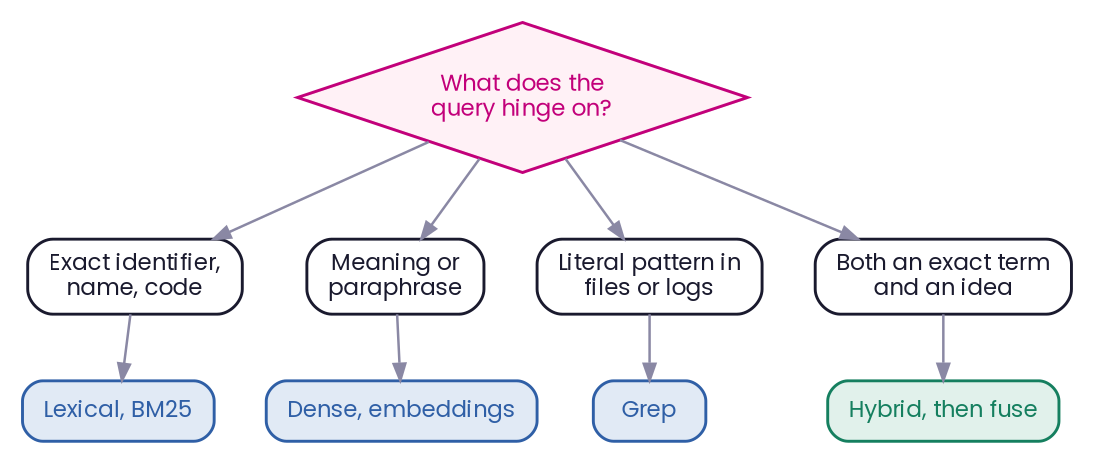

*Own construction. The decision runner below executes it on three real queries.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart TD
    q{"What does the<br/>query hinge on?"}
    id["Exact identifier,<br/>name, code"]
    mean["Meaning or<br/>paraphrase"]
    pat["Literal pattern in<br/>files or logs"]
    both["Both an exact term<br/>and an idea"]
    lex["Lexical, BM25"]
    den["Dense, embeddings"]
    grep["Grep"]
    hyb["Hybrid, then fuse"]
    q --> id
    q --> mean
    q --> pat
    q --> both
    id --> lex
    mean --> den
    pat --> grep
    both --> hyb
    class q dec
    class lex tool
    class den tool
    class grep tool
    class hyb ok
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [8]:
def signal(query):
    toks = rk.tokenize(query, keep_stop=True)
    has_id = any(t[0].isdigit() or "-" in t or t.isupper() for t in query.split())
    proper = sum(1 for w in query.split()[1:] if w[:1].isupper())
    return {"has_identifier": has_id, "proper_nouns": proper, "n_tokens": len(toks)}

MODE_TREE = [
    {"q": "Does the query contain a literal identifier or code?", "test": lambda f: f["has_identifier"], "yes": "grep, then lexical as a fallback", "no": None,
     "show": lambda f: f"has_identifier={f['has_identifier']}"},
    {"q": "Does it carry a proper noun that will appear verbatim in the source?", "test": lambda f: f["proper_nouns"] >= 1, "yes": None, "no": "dense retrieval, the query is meaning-only",
     "show": lambda f: f"proper_nouns={f['proper_nouns']}"},
    {"q": "Is it also long enough to carry an idea beyond the name?", "test": lambda f: f["n_tokens"] >= 6, "yes": "hybrid, lexical for the name plus dense for the idea, then fuse", "no": "lexical, the name is the whole query",
     "show": lambda f: f"n_tokens={f['n_tokens']}"},
]
for q in ["ERR-4471", "Nord Aerospace", anchor.text]:
    display(table(decision(MODE_TREE, signal(q)), f"Decision path for: {q[:60]}"))

question,measured,answer
Does the query contain a literal identifier or code?,has_identifier=True,yes
Outcome,,"grep, then lexical as a fallback"


question,measured,answer
Does the query contain a literal identifier or code?,has_identifier=False,no
Does it carry a proper noun that will appear verbatim in the source?,proper_nouns=1,yes
Is it also long enough to carry an idea beyond the name?,n_tokens=2,no
Outcome,,"lexical, the name is the whole query"


question,measured,answer
Does the query contain a literal identifier or code?,has_identifier=True,yes
Outcome,,"grep, then lexical as a fallback"


| If | Then reach for | Because |
|---|---|---|
| The query hinges on an exact identifier, code, name or error string. | Lexical retrieval with BM25, or grep when the source is a file. | An exact token match is precise and cheap, and it does not drift to lookalikes. |
| The query hinges on meaning, intent or a paraphrase of the source wording. | Semantic retrieval with dense vectors. | Embeddings place related meanings near each other even when the words differ. |
| The query carries both an exact term and a paraphrased idea, as the worked question does. | A hybrid of lexical and semantic, fused by rank. | Each mode covers the other's blind spot, and fusion keeps items that both rank well. |

The runner is a heuristic over surface features and it is written that way on purpose: in production the same decision is usually made per query by a small router, and the router itself needs an evaluation.

## 5 · The pipeline is a recall budget spent on precision

First-stage retrieval buys recall cheaply over the whole corpus. Every later stage can only lose evidence, never recreate it. So the question to ask of stage one is not whether the top 5 is right, but whether the gold evidence is anywhere in a wide candidate pool.

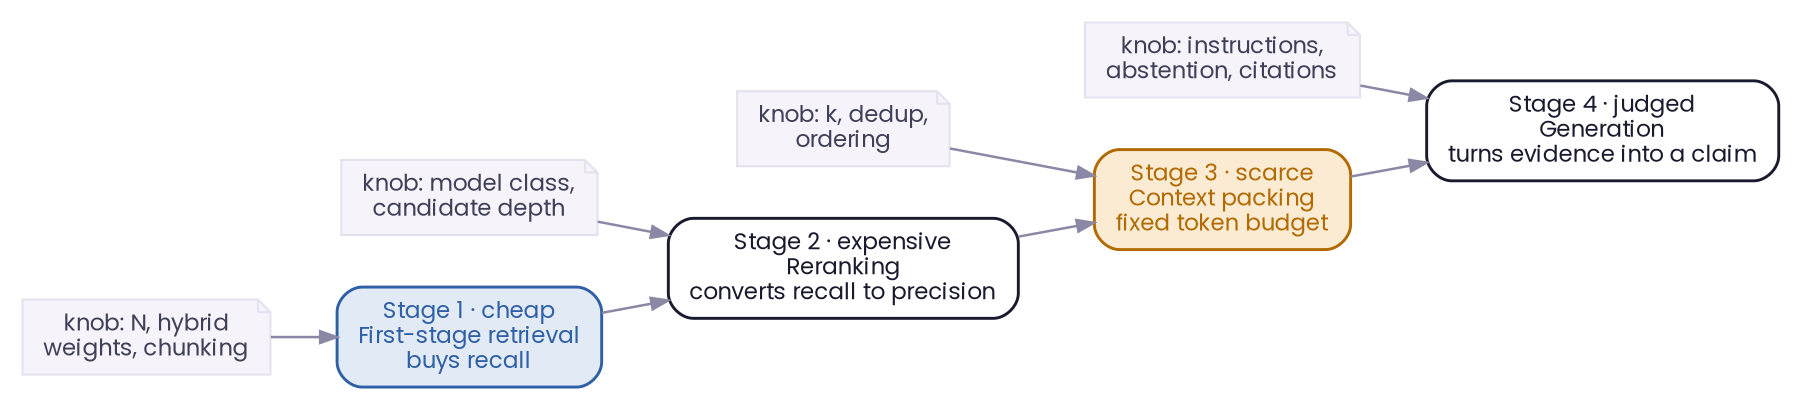

*Mental model taken from the advanced-track deck. Anything lost at stage one is lost permanently.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    s1["Stage 1 · cheap<br/>First-stage retrieval<br/>buys recall"]
    s2["Stage 2 · expensive<br/>Reranking<br/>converts recall to precision"]
    s3["Stage 3 · scarce<br/>Context packing<br/>fixed token budget"]
    s4["Stage 4 · judged<br/>Generation<br/>turns evidence into a claim"]
    n1["knob: N, hybrid<br/>weights, chunking"]
    n2["knob: model class,<br/>candidate depth"]
    n3["knob: k, dedup,<br/>ordering"]
    n4["knob: instructions,<br/>abstention, citations"]
    s1 --> s2
    s2 --> s3
    s3 --> s4
    n1 --> s1
    n2 --> s2
    n3 --> s3
    n4 --> s4
    class s1 tool
    class s3 cost
    class n1 note
    class n2 note
    class n3 note
    class n4 note
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

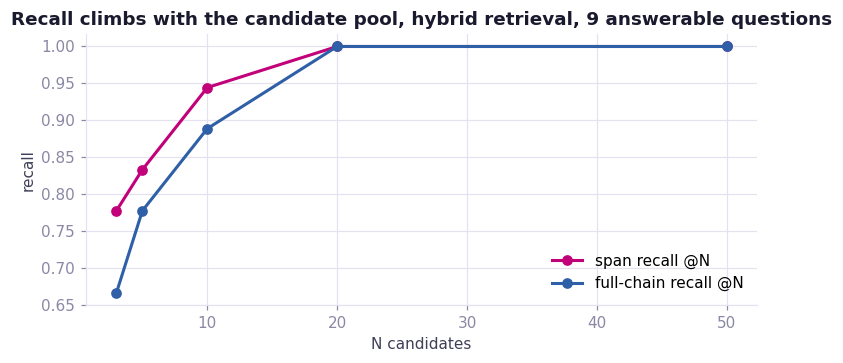

N,span recall,full-chain recall
3,0.778,0.667
5,0.833,0.778
10,0.944,0.889
20,1.000,1.000
50,1.000,1.000


In [9]:
answerable = [q for q in questions if q.gold]
Ns = [3, 5, 10, 20, 50]
recall_at_N, chain_at_N = [], []
for N in Ns:
    r, ch = [], []
    for q in answerable:
        gs = rk.gold_chunk_sets(q, chunks)
        ids = [cid for cid, _ in retriever.hybrid(q.text, k=50)]
        r.append(rk.evidence_recall_at_k(gs, ids, N)); ch.append(rk.full_chain_recall(gs, ids, N))
    recall_at_N.append(np.mean(r)); chain_at_N.append(np.mean(ch))
lines(Ns, {"span recall @N": recall_at_N, "full-chain recall @N": chain_at_N}, "Recall climbs with the candidate pool, hybrid retrieval, 9 answerable questions", "N candidates", "recall")
table(pd.DataFrame({"N": Ns, "span recall": np.round(recall_at_N, 3), "full-chain recall": np.round(chain_at_N, 3)}), "Measured on this corpus")

| Stage | What it can fix | What it cannot fix | The number to measure before touching it |
|---|---|---|---|
| Stage 1, first-stage retrieval | Whether the gold evidence is in the pool at all. | Nothing downstream; it only supplies candidates. | Full-chain recall at N, with N in the tens, as in the curve above. |
| Stage 2, reranking | The order of the pool, so gold rises above distractors. | A gold chunk that is not in the pool. | Full-chain recall at k after reranking, compared with stage one at the same k. |
| Stage 3, packing | Which of the ranked chunks fit the token budget, and in what order. | Anything the reranker put below the cut. | Coverage of gold spans in the packed context. |
| Stage 4, generation | Whether the claim is grounded, cited and abstains when it should. | Missing evidence. | Correctness and faithfulness, scored together. |

The single most common architectural mistake is tuning stage two or three to fix a recall problem created in stage one. The curve tells you which case you are in: if full-chain recall is low at N=50, the problem is upstream of every reranker.

## 6 · Three ways to tell whether a change helped

| Evaluation mode | The question it answers | What it costs you |
|---|---|---|
| Offline, on a fixed labelled set | Did this change move a metric against known-good answers? | You must build and maintain a labelled set that reflects real queries. Notebook 02 builds one. |
| Online, with real traffic | Do real users behave better with the change than without it? | You need traffic, guardrails, and time for a result to become trustworthy. |
| An LLM as a judge | Does a strong model rate this answer higher on a written rubric? | The judge has its own bias and drift, so it needs calibration. Notebook 06 calibrates one. |

The cell below is the offline mode in its simplest form: the same benchmark, three retrieval modes, one table.

In [10]:
runs = {}
for mode in ["lexical", "dense", "hybrid"]:
    cfg = rk.RunConfig(name=mode, mode=mode, n_pool=50, k=5)
    runs[mode] = rk.summarize(rk.run_benchmark(cfg, retriever, generator, questions, chunks, store), mode)
table(pd.DataFrame(runs).T.reset_index().rename(columns={"index": "mode"}), "Offline evaluation at k=5. Retrieval metrics average the 9 answerable questions; correct and faithful average all 12.")

mode,recall@k,full_chain@k,recall@pool,ndcg@k,coverage,correct,faithful,null_abstained,evidence_tokens
lexical,0.833,0.778,1.000,0.823,0.833,0.833,1.000,1.000,225.083
dense,0.833,0.778,1.000,0.819,0.833,0.833,1.000,1.000,234.000
hybrid,0.833,0.778,1.000,0.823,0.833,0.833,1.000,1.000,229.167


Read the table across, not down. Full-chain recall at k=5 is the multi-hop number, and it is the one that separates the modes. Correctness follows it almost exactly, because the generator here is grounded by construction. With a real model the two would diverge, and that gap is what faithfulness measures in notebook 06.

## 7 · Measure each handoff, then let a tree name the owning stage

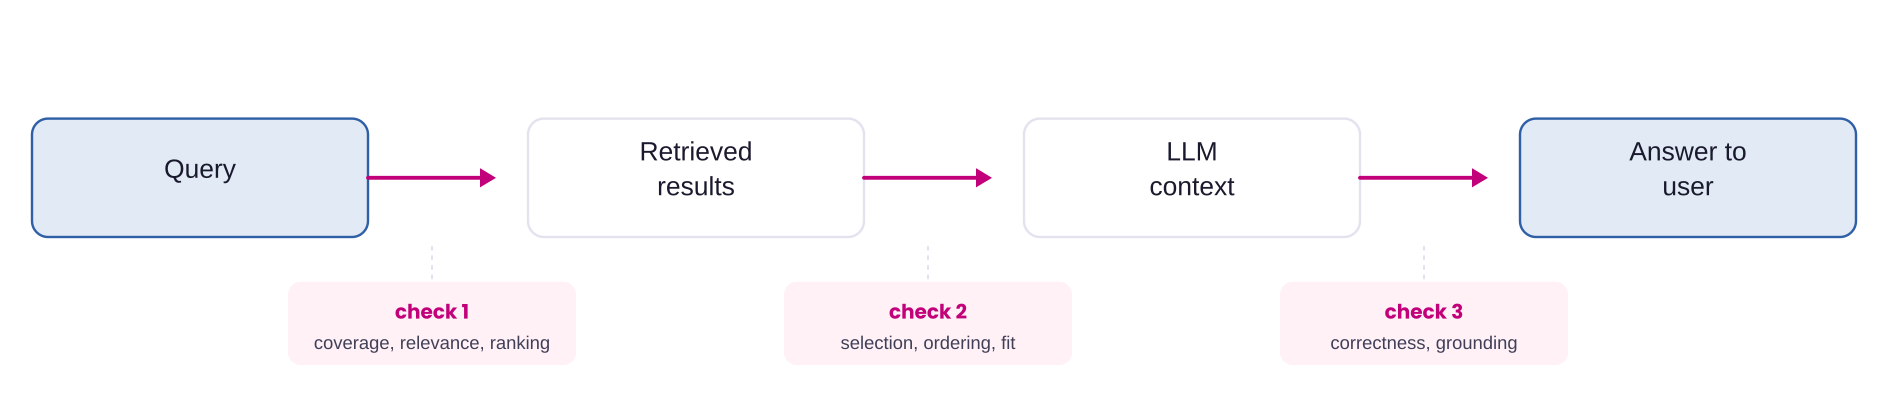

*A single end score hides which stage failed. Three checks, one per handoff, name it.*

In [11]:
cfg = rk.RunConfig(name="hybrid_k5", mode="hybrid", n_pool=50, k=5)
pool = retriever.hybrid(anchor.text, k=cfg.n_pool)
pool_ids = [cid for cid, _ in pool]
packed = rk.pack(pool, texts, evidence_cap=6000, k=cfg.k)
ans = generator.answer(anchor, packed.chunk_ids, texts)
print("gold chunks rank in the pool:", {sorted(s)[0]: pool_ids.index(sorted(s)[0]) + 1 for s in gold_sets})
display(verdict_style(rk.handoffs(anchor, gold_sets, pool_ids, packed.chunk_ids, ans.text, texts, k_pool=50), "verdict"))
display(table(rk.fault_tree(gold_sets, pool_ids, packed.chunk_ids, ans.text, anchor, texts), "The four-question fault tree, executed on this trace"))

packed20 = rk.pack(pool, texts, evidence_cap=6000, k=20)
ans20 = generator.answer(anchor, packed20.chunk_ids, texts)
print("\nwith k=20 the same pool yields:", ans20.text)

gold chunks rank in the pool: {'a1:0:63d9a4f8': 7, 'b7:0:d9956799': 19}


handoff,what it checks,score,verdict
1. query to retrieval,gold evidence in the candidate pool,1.000,pass
2. retrieval to context,gold evidence survived packing,0.000,FAIL
3. context to answer,answer correct and supported,0.000,FAIL


question,answer
Q1 Is every gold span in the packed context?,no
Q2 Was every gold chunk in the candidate pool?,yes
Owning stage,"ranking or packing fault: reranker, fusion, k, dedup, truncation"



with k=20 the same pool yields: Vega Dynamics, 2023 [a1:0:63d9a4f8] [b7:0:d9956799]


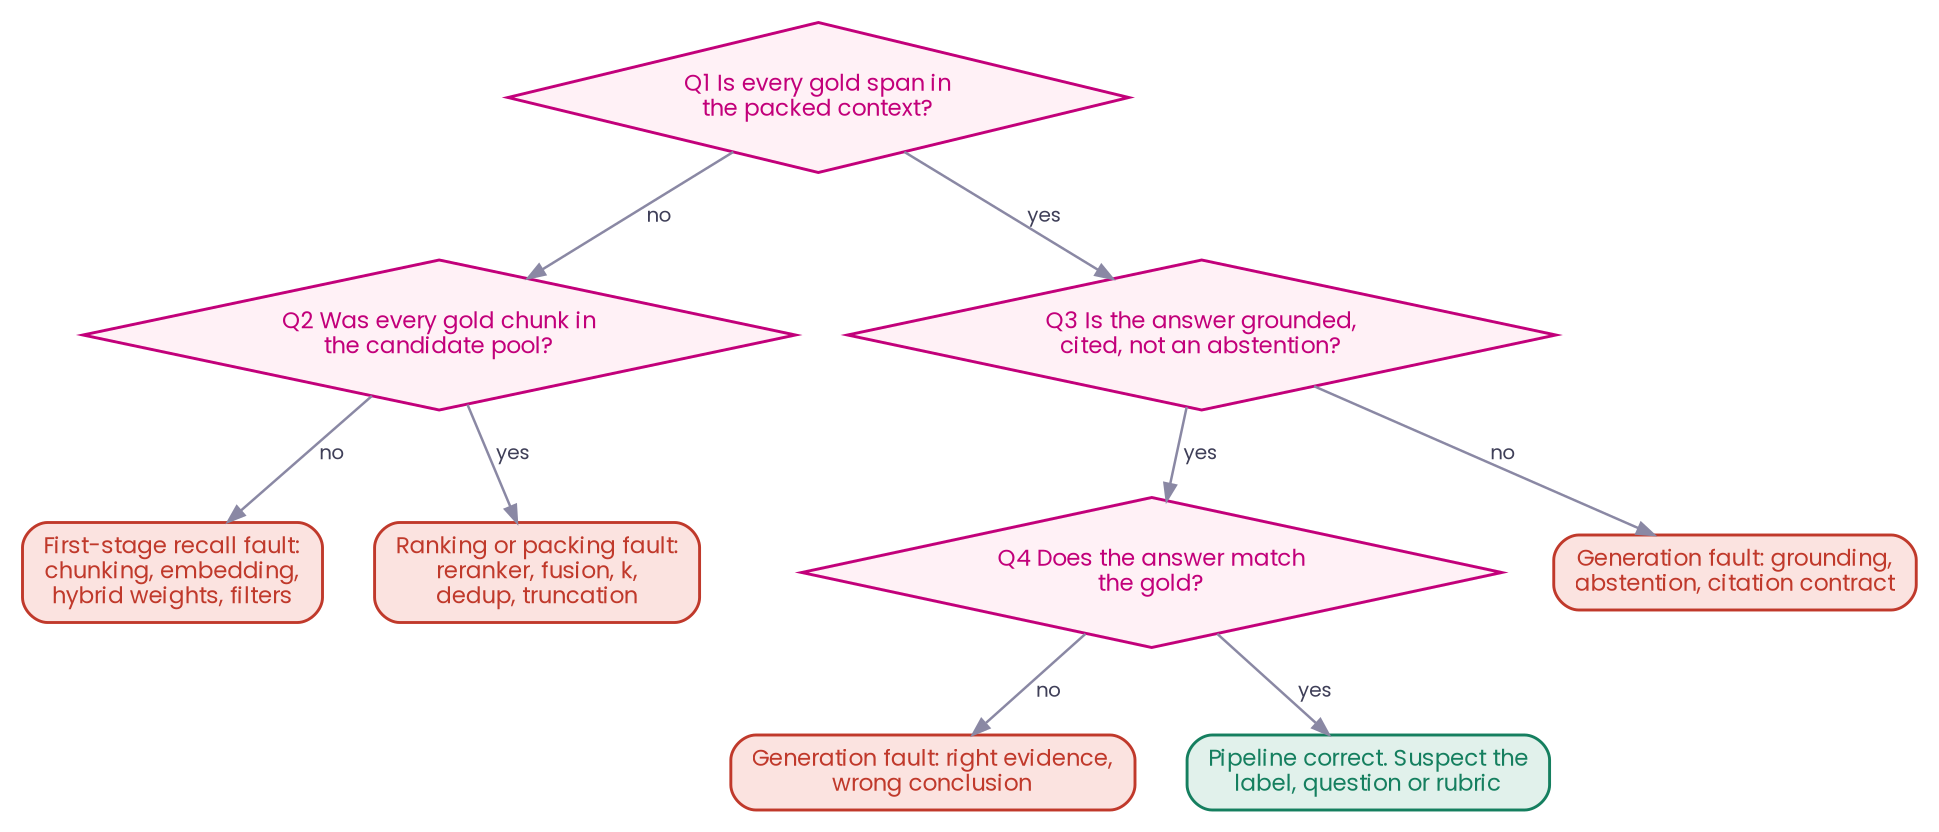

*The fault-isolation tree from the advanced-track deck. Four questions reach a single owning stage.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart TD
    q1{"Q1 Is every gold span in<br/>the packed context?"}
    q2{"Q2 Was every gold chunk in<br/>the candidate pool?"}
    q3{"Q3 Is the answer grounded,<br/>cited, not an abstention?"}
    q4{"Q4 Does the answer match<br/>the gold?"}
    f1["First-stage recall fault:<br/>chunking, embedding,<br/>hybrid weights, filters"]
    f2["Ranking or packing fault:<br/>reranker, fusion, k,<br/>dedup, truncation"]
    f3["Generation fault: grounding,<br/>abstention, citation contract"]
    f4["Generation fault: right evidence,<br/>wrong conclusion"]
    ok["Pipeline correct. Suspect the<br/>label, question or rubric"]
    q1 -->|no| q2
    q1 -->|yes| q3
    q2 -->|no| f1
    q2 -->|yes| f2
    q3 -->|no| f3
    q3 -->|yes| q4
    q4 -->|no| f4
    q4 -->|yes| ok
    class q1 dec
    class q2 dec
    class q3 dec
    class q4 dec
    class f1 fail
    class f2 fail
    class f3 fail
    class f4 fail
    class ok ok
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

| If the tree stops at | The fault sits in | So the first fix to try |
|---|---|---|
| Q2 answered no | First-stage recall, and possibly the index behind it. | Widen N, switch to hybrid, or revisit chunking. Notebook 03. |
| Q2 answered yes | Ranking or packing, which is where the worked question failed above: both gold chunks were in the pool of 50, at ranks 7 and 19, and k=5 cut them. | Rerank the pool or raise k. Notebook 04 and 05. |
| Q3 answered no | Generation controls. | Grounding instruction, citation contract, abstention policy. Notebook 05. |
| Q4 answered no | The model read the right evidence and still concluded wrongly. | Model choice, or the rubric itself. Notebook 06. |
| Q4 answered yes | Nothing in the pipeline. | Check the label. Ambiguous gold answers are an under-reported source of regressions. |

## 8 · Four failures that never throw an error

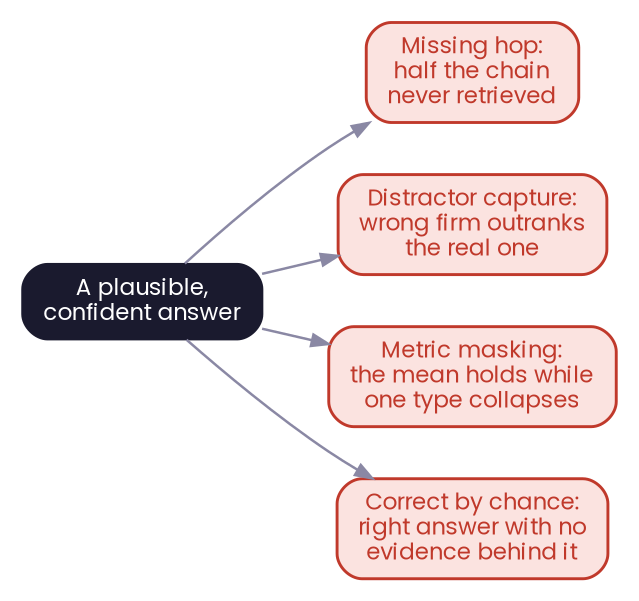

*Each one shows up as a fluent answer that happens to be wrong, or a right answer that will not survive the next release.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    s(["A plausible,<br/>confident answer"])
    a["Missing hop:<br/>half the chain<br/>never retrieved"]
    b["Distractor capture:<br/>wrong firm outranks<br/>the real one"]
    c["Metric masking:<br/>the mean holds while<br/>one type collapses"]
    d["Correct by chance:<br/>right answer with no<br/>evidence behind it"]
    s --> a
    s --> b
    s --> c
    s --> d
    class s start
    class a fail
    class b fail
    class c fail
    class d fail
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [12]:
# (a) the missing hop: already seen in section 3. Half the chain arrives, the grounded generator abstains, an ungrounded one would guess.

# (b) distractor capture: a query about the 2026 appointment pulls the wrong firm alongside the right one
q = "which aerospace company appointed a new chief executive in 2026"
display(table(retriever.show(retriever.hybrid(q, k=4)), "(b) Vela Systems and Nord Aerospace compete on the same tokens"))

# (c) metric masking: the mean hides the type that fails
df_dense = rk.run_benchmark(rk.RunConfig("dense_k5", mode="dense", k=5), retriever, generator, questions, chunks)
by_type = df_dense.groupby("type")[["full_chain@k", "correct"]].mean().round(2).reset_index()
print(f"(c) mean correctness = {df_dense['correct'].mean():.2f}, but by type:")
display(table(by_type, "(c) The inference type, the dependent multi-hop questions, is where the baseline fails"))

# (d) correct by chance: an ungrounded generator gets q01 right with zero evidence
ungrounded = rk.MockGenerator(p_parametric=1.0)
df_ung = rk.run_benchmark(rk.RunConfig("dense_k5_ungrounded", mode="dense", k=5), retriever, ungrounded, questions, chunks)
cells = df_ung["cell"].value_counts().rename_axis("attribution cell").reset_index(name="questions")
display(table(cells, "(d) With p_parametric=1.0 the answerable questions are all correct; the ones with no evidence are correct by chance, and the null questions are fabricated"))

rank,chunk_id,doc,date,score,text
1,l3:1:b31c0299,l3,2025-09-30,0.033,Lumen Bio phase 3 trial meets primary endpoint. Chief executive Amir Sadeghi said the comp...
2,a1:0:63d9a4f8,a1,2026-03-12,0.032,"Nord Aerospace names Elena Ruiz chief executive. Nord Aerospace, the Bergen-based launch-v..."
3,k3:1:3ea2bfbe,k3,2026-02-03,0.032,Kestrel Foods revenue flat at 3.1 billion euros. The company said it expected modest growt...
4,d3:0:de051818,d3,2026-04-02,0.032,"Vela Systems appoints Marcus Hale as chief executive. Vela Systems, the Turin-based maker ..."


(c) mean correctness = 0.83, but by type:


type,full_chain@k,correct
comparison,1.000,1.000
inference,0.330,0.330
null,nan,1.000
temporal,1.000,1.000


attribution cell,questions
healthy,7
fabrication on null,3
correct by chance,2


| Silent failure | What you saw | Which metric catches it |
|---|---|---|
| Missing hop | The pool held one article's chunk in the top 5 and the other at rank 19. | Full-chain recall, not span recall, since the mean of the two spans hides that only one arrived. |
| Distractor capture | Vela Systems ranked next to Nord Aerospace on the same tokens. | Precision at k, and later a reranker that reads query and passage together. |
| Metric masking | Mean correctness of 0.83 hid an inference-type score of 0.33. | Any metric segmented by question type, slice or tenant. |
| Correct by chance | Every answerable question scored correct with no evidence packed. | Faithfulness alongside correctness, which is the attribution 2x2 in notebook 06. |

## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | Retrieval sets the ceiling on answer quality, so the generator can only be as good as the evidence it is handed. Coverage went from 0.0 to 1.0 and nothing else changed. |
| 2 | There are three retrieval modes, and you pick among lexical, semantic and grep by the signal the query hinges on. Production runs the first two together and fuses them. |
| 3 | Stage one buys recall over a wide pool; every later stage can only spend it. Measure full-chain recall at N before you touch a reranker. |
| 4 | You measure the three handoffs separately and let the four-question tree name the owning stage. The worked question failed at ranking, not at recall. |
| 5 | Most real failures are silent, so you segment metrics by type and score faithfulness next to correctness. |

**Next: 02 · The MultiHop benchmark.** The eval set you just measured against was handed to you. Notebook 02 shows what a benchmark record is scored against, why the null questions matter, and how to manufacture an eval set from a client corpus that has no labels.

## Try it

Change `K` and `MODE` and rerun the cell. Watch full-chain recall and the attribution cells move together.

In [13]:
K, MODE = 8, "hybrid"
df_try = rk.run_benchmark(rk.RunConfig(f"{MODE}_k{K}", mode=MODE, n_pool=50, k=K), retriever, generator, questions, chunks)
display(table(df_try[["qid", "type", "full_chain@k", "coverage", "correct", "cell"]], f"{MODE} at k={K}"))
rk.summarize(df_try, f"{MODE}_k{K}")

qid,type,full_chain@k,coverage,correct,cell
q01,inference,0.000,0.500,0.000,retrieval failure
q02,inference,1.000,1.000,1.000,healthy
q03,inference,0.000,0.500,0.000,retrieval failure
q04,comparison,1.000,1.000,1.000,healthy
q05,comparison,1.000,1.000,1.000,healthy
q06,comparison,1.000,1.000,1.000,healthy
q07,temporal,1.000,1.000,1.000,healthy
q08,temporal,1.000,1.000,1.000,healthy
q09,temporal,1.000,1.000,1.000,healthy
q10,null,nan,nan,1.000,healthy


recall@k             0.889
full_chain@k         0.778
recall@pool          1.000
ndcg@k               0.846
coverage             0.889
correct              0.833
faithful             1.000
null_abstained       1.000
evidence_tokens    347.500
Name: hybrid_k8, dtype: float64

## Interview corner

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| Walk me through why retrieval sets the ceiling on answer quality. | Separates the ceiling set by evidence selection from the model's own competence, and names coverage as the number that proves it. | Talks only about prompt wording or model size. |
| Your accuracy metric is flat but users say it got worse. What could be happening? | Segments the metric by type and slice, pulls traces, and walks the handoffs to localise the change. | Concludes nothing changed because the top-line number held. |
| Given a query, how would you choose between lexical and semantic retrieval? | Reads the signal in the query, and defaults to hybrid with fusion when both signals are present. | Picks one mode for every query. |